##1) Problem statement
  This project understands how the student's performance (test scores) is affected by other variables such as Gender, Ethnicity, Parental level of education, Lunch and Test preparation course.
##2) Data Collection
Dataset Source - https://www.kaggle.com/datasets/spscientist/students-performance-in-exams?datasetId=74977
The data consists of 8 column and 1000 rows.

In [1]:
## Importing Important Library

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
## Importing Data

df = pd.read_csv('stud.csv')

In [3]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
df.shape

(1000, 8)

# Dataset information

1.   gender : sex of students -> (Male/female)
2.   race/ethnicity : ethnicity of students -> (Group A, B,C, D,E)
3.   parental level of education : parents' final education ->(bachelor's degree,some college,master's degree,associate's degree,high school)
4.   lunch : having lunch before test (standard or free/reduced)
5.   test preparation course : complete or not complete before test
6.   math score
7.   reading score
8.   writing score





In [6]:
df.isnull().sum()

,0
gender,0
race_ethnicity,0
parental_level_of_education,0
lunch,0
test_preparation_course,0
math_score,0
reading_score,0
writing_score,0


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [9]:
## Checking the no. of unique value

df.nunique()

,0
gender,2
race_ethnicity,5
parental_level_of_education,6
lunch,2
test_preparation_course,2
math_score,81
reading_score,72
writing_score,77


In [10]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Insight



*   From above description of numerical data mean are very close to each other 66 and 68.05
*   standard deviation are between 14.6 and 15.19





## Exploring Data

In [11]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [18]:
print("Categories in 'gender' Variable: ", df['gender'].unique())

print("Categories in 'race_ethnicity' is: ", df['race_ethnicity'].unique())

print("Categories in 'parental_level_of_education' is: ", df['parental_level_of_education'].unique())

print("Categories in 'lunch' is: ", df['lunch'].unique())

print("Categories in 'test_preparation_course' is: ", df['test_preparation_course'].unique())

Categories in 'gender' Variable:  ['female' 'male']
Categories in 'race_ethnicity' is:  ['group B' 'group C' 'group A' 'group D' 'group E']
Categories in 'parental_level_of_education' is:  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Categories in 'lunch' is:  ['standard' 'free/reduced']
Categories in 'test_preparation_course' is:  ['none' 'completed']


In [22]:
## define numerical and categorical columns

numeric_feature = [feature for feature in df.columns if df[feature].dtype != 'O' ]
categorical_feature = [feature for feature in df.columns if df[feature].dtype == 'O']

## print
print(f"We have {len(numeric_feature)} numerical feature : {numeric_feature}")
print(f"We have {len(categorical_feature)} categorical feature: {categorical_feature}")

We have 3 numerical feature : ['math_score', 'reading_score', 'writing_score']
We have 5 categorical feature: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


## Adding Columns for "Total Score" and "Average"

In [25]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average_score'] = round(df['total_score'] / 3, 2)

In [26]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.67
1,female,group C,some college,standard,completed,69,90,88,247,82.33
2,female,group B,master's degree,standard,none,90,95,93,278,92.67
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.33
4,male,group C,some college,standard,none,76,78,75,229,76.33


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   gender                       1000 non-null   object 
 1   race_ethnicity               1000 non-null   object 
 2   parental_level_of_education  1000 non-null   object 
 3   lunch                        1000 non-null   object 
 4   test_preparation_course      1000 non-null   object 
 5   math_score                   1000 non-null   int64  
 6   reading_score                1000 non-null   int64  
 7   writing_score                1000 non-null   int64  
 8   total_score                  1000 non-null   int64  
 9   average_score                1000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 78.3+ KB


In [36]:
reading_full = df[df['reading_score'] == 100]['average_score'].count()
writing_full = df[df['writing_score'] == 100]['average_score'].count()
math_full = df[df['math_score'] == 100]['average_score'].count()

print(f"Number of students with full marks in Reading: ", reading_full)
print(f"Number of students with full marks in Writing: ", writing_full)
print(f"Number of students with full marks in MAth: ", math_full)


Number of students with full marks in Reading:  17
Number of students with full marks in Writing:  14
Number of students with full marks in MAth:  7


In [37]:
reading_less_20 = df[df['reading_score'] <= 20]['average_score'].count()
writing_less_20 = df[df['writing_score'] <= 20]['average_score'].count()
math_less_20 = df[df['math_score'] <= 20]['average_score'].count()

print(f"Number of students with less than 20 marks in Reading: ", reading_less_20)
print(f"Number of students with less than 20 marks in Writing: ", writing_less_20)
print(f"Number of students with less than 20 marks in MAth: ", math_less_20)

Number of students with less than 20 marks in Reading:  1
Number of students with less than 20 marks in Writing:  3
Number of students with less than 20 marks in MAth:  4


## Exploring Data (Visualization)

## 4.1 Visualize average score distribution to make some conclusion.
  Histogram
  
  Kernel Distribution Function (KDE)

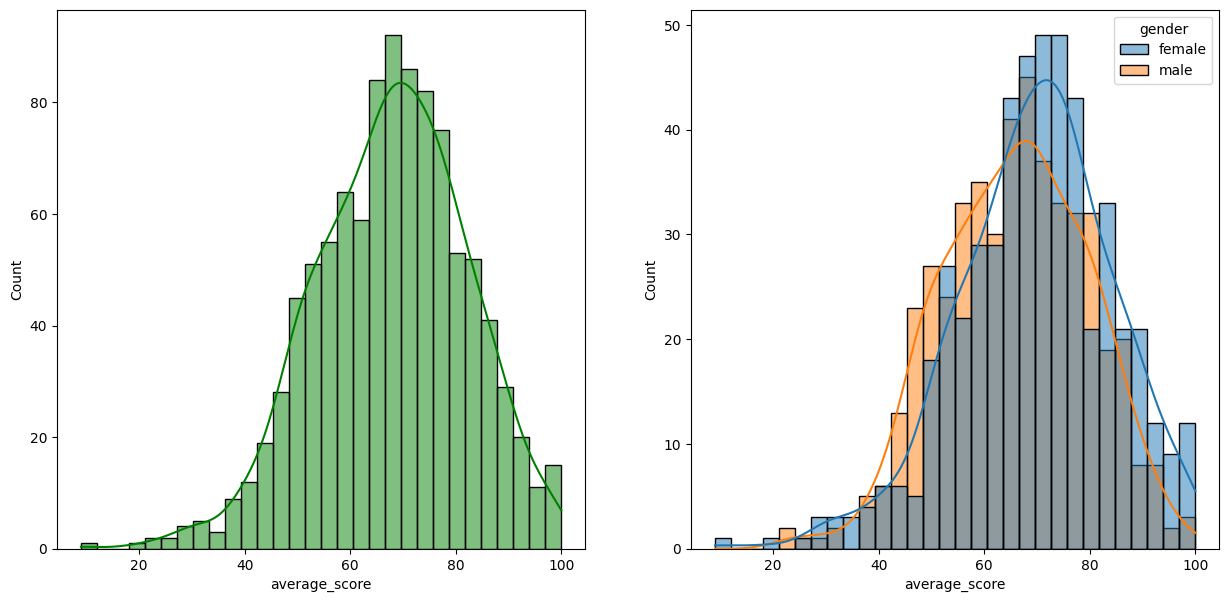

In [40]:
fig, axs = plt.subplots(1, 2, figsize=(15,7))
plt.subplot(1,2,1)
sns.histplot(data=df, x='average_score', bins=30, kde=True, color='g')
plt.subplot(1,2,2)
sns.histplot(data=df, x='average_score', bins=30, kde=True, hue='gender')
plt.show()

# Insight

*  Female student tends to perform more than male students




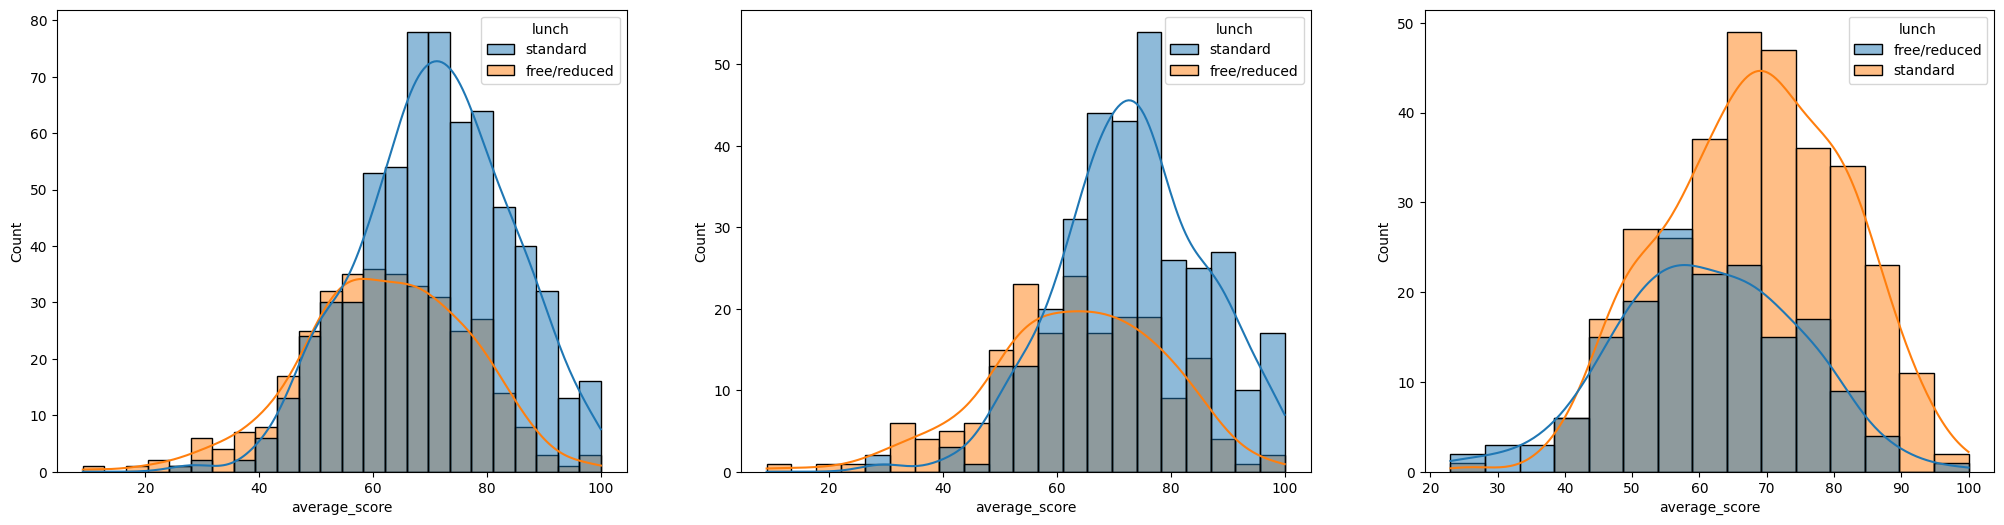

In [42]:
plt.subplots(1, 3, figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df, x='average_score', kde=True, hue='lunch')
plt.subplot(1,3,2)
sns.histplot(data=df[df['gender'] == 'female'], x='average_score', kde=True, hue='lunch')
plt.subplot(1,3,3)
sns.histplot(data=df[df['gender'] == 'male'], x='average_score', kde=True, hue='lunch')
plt.show()

## Insights
   Standard lunch helps perform well in exams.

   Standard lunch helps perform well in exams be it a male or a female.

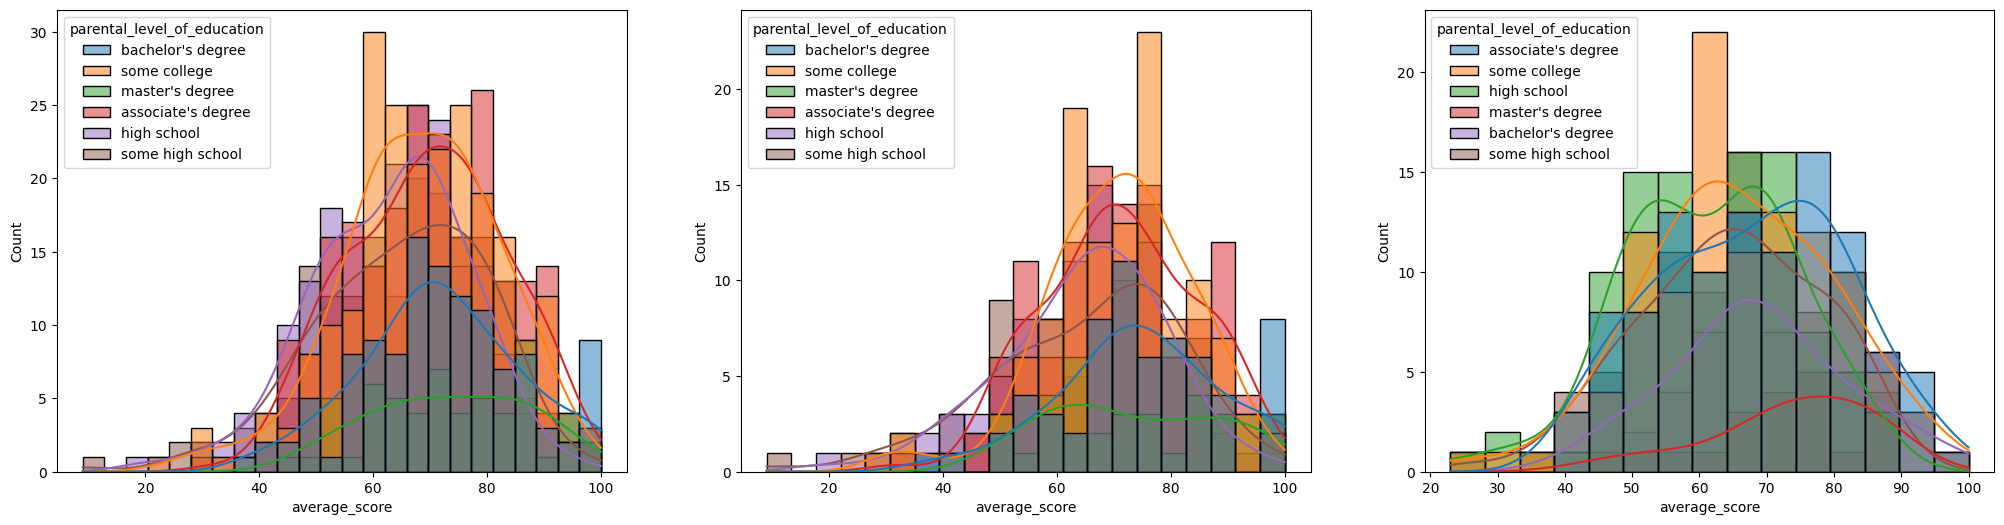

In [44]:
plt.subplots(1, 3, figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df, x='average_score', kde=True, hue='parental_level_of_education')
plt.subplot(1,3,2)
sns.histplot(data=df[df['gender'] == 'female'], x='average_score', kde=True, hue='parental_level_of_education')
plt.subplot(1,3,3)
sns.histplot(data=df[df['gender'] == 'male'], x='average_score', kde=True, hue='parental_level_of_education')
plt.show()

 ## Insight  
   1. In general parent's education don't help student perform well in exam.
   2. 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
   3. 3rd plot we can see there is no effect of parent's education on female students.

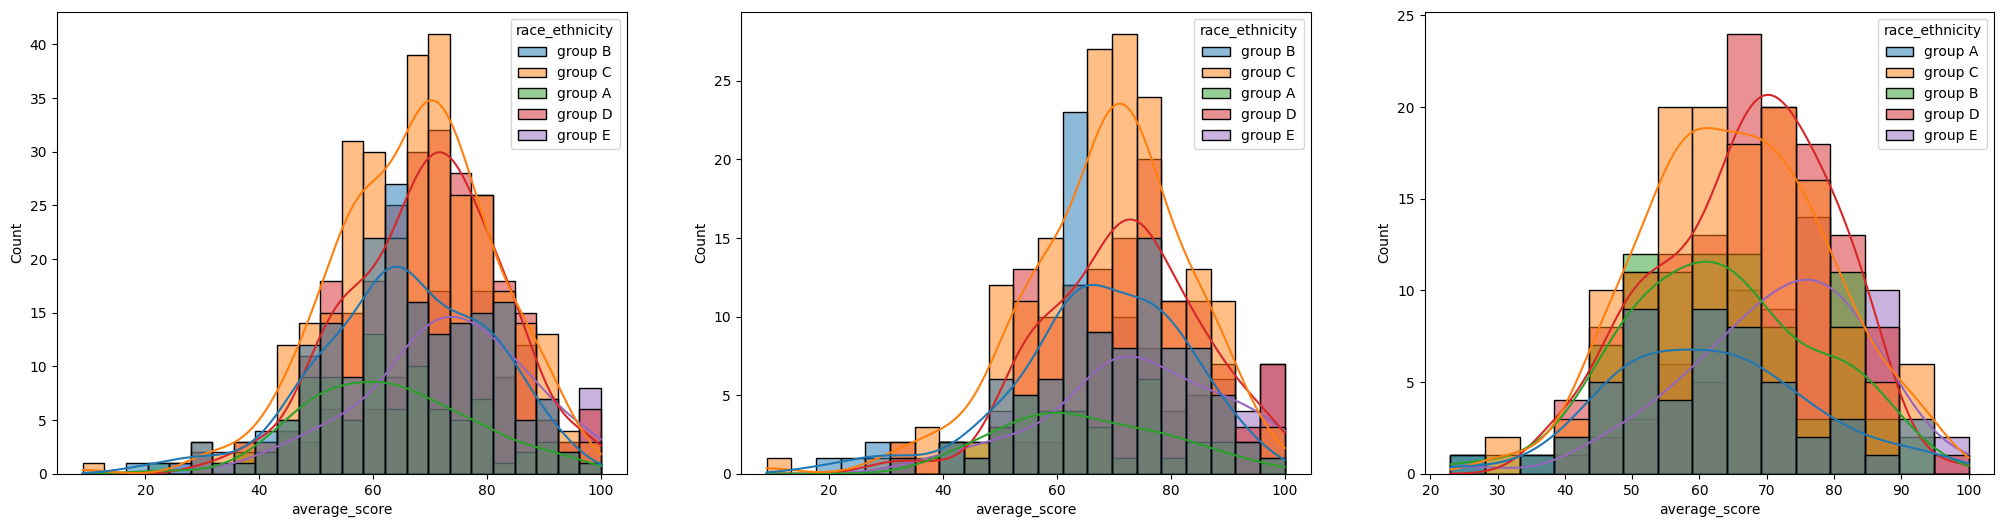

In [45]:
plt.subplots(1, 3, figsize=(25,6))
plt.subplot(1,3,1)
sns.histplot(data=df, x='average_score', kde=True, hue='race_ethnicity')
plt.subplot(1,3,2)
sns.histplot(data=df[df['gender'] == 'female'], x='average_score', kde=True, hue='race_ethnicity')
plt.subplot(1,3,3)
sns.histplot(data=df[df['gender'] == 'male'], x='average_score', kde=True, hue='race_ethnicity')
plt.show()

## Insights
  1. Students of group A and group B tends to perform poorly in exam.
  2. Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

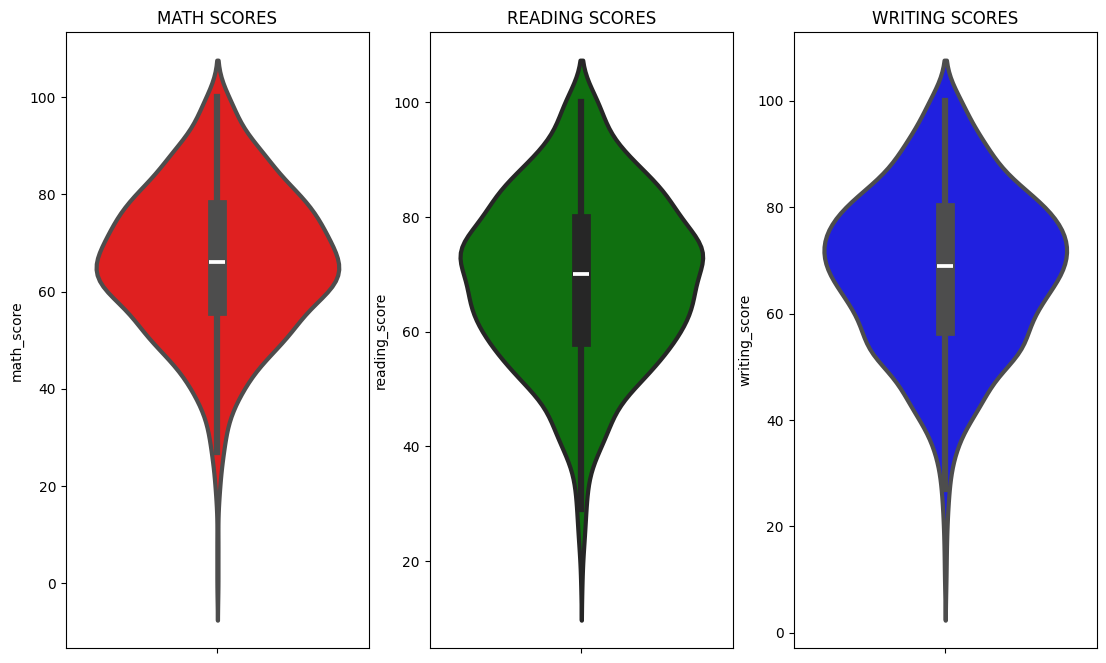

In [47]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

## Insights

   From the above three plots its clearly visible that most of the students score
in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

## BIVARIATE ANALYSIS

<Axes: xlabel='lunch', ylabel='writing_score'>

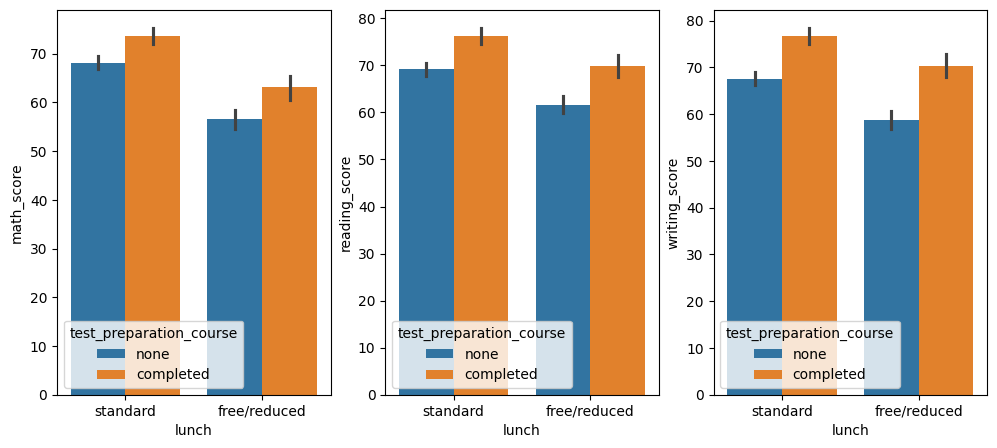

In [55]:
plt.subplots(1,3,figsize=(12,5))
plt.subplot(1,3,1)
sns.barplot (data=df, x=df['lunch'], y=df['math_score'], hue=df['test_preparation_course'])
plt.subplot(1,3,2)
sns.barplot (data=df, x=df['lunch'], y=df['reading_score'], hue=df['test_preparation_course'])
plt.subplot(1,3,3)
sns.barplot (data=df, x=df['lunch'], y=df['writing_score'], hue=df['test_preparation_course'])

## Insights
Students who have completed the Test Prepration Course have scores higher in all three categories than those who haven't taken the course

## Checking Outliers

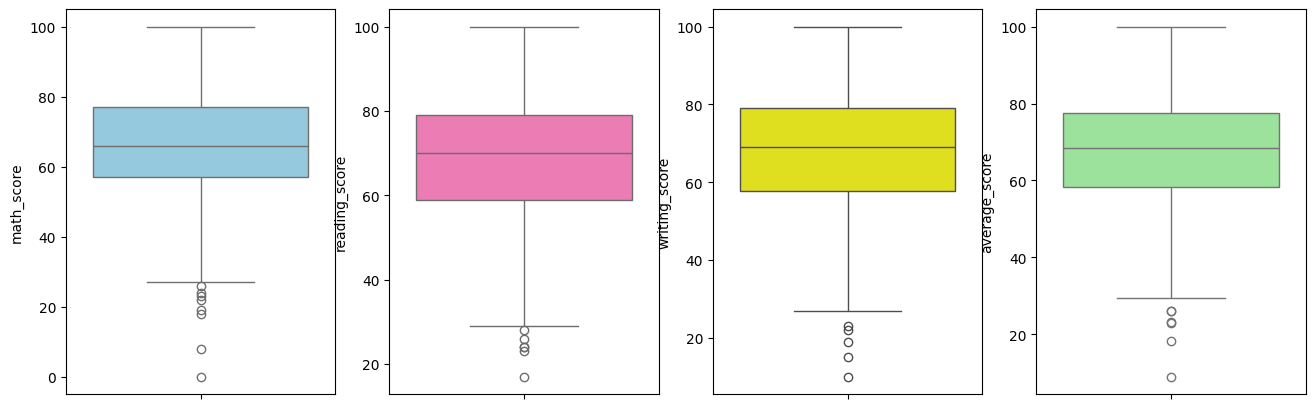

In [48]:
plt.subplots(1,4,figsize=(16,5))
plt.subplot(141)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(142)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(143)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(144)
sns.boxplot(df['average_score'],color='lightgreen')
plt.show()

## MUTIVARIATE ANALYSIS USING PAIRPLOT

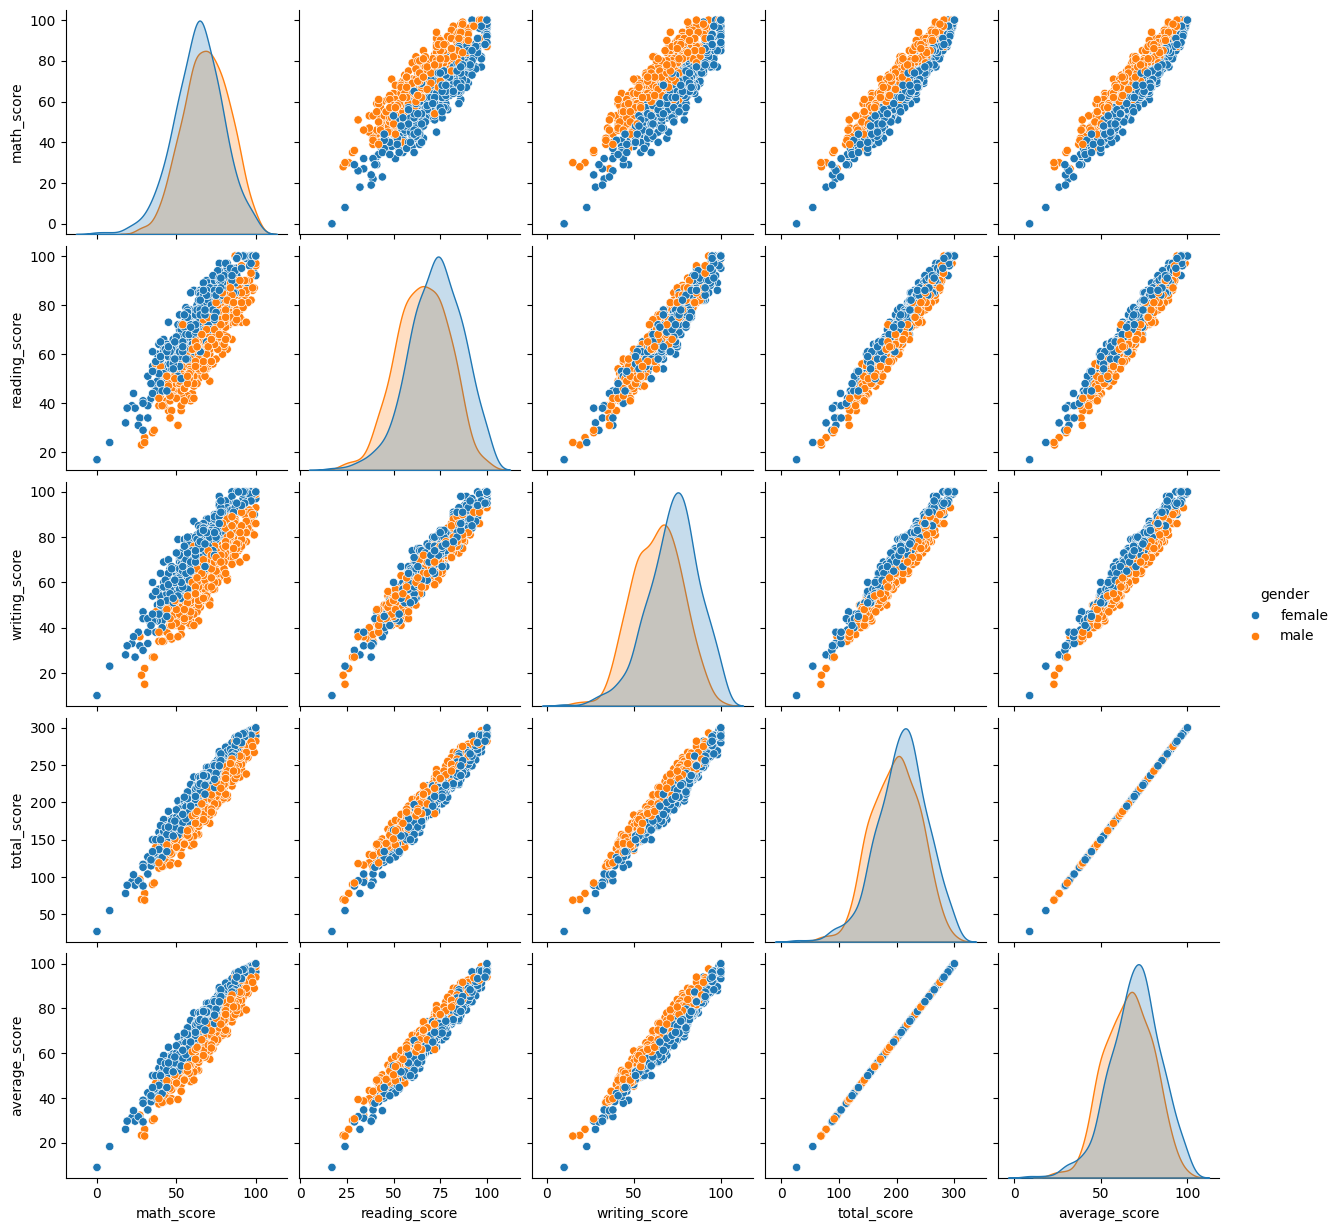

In [50]:
sns.pairplot(df, hue='gender')
plt.show()

## Insights


From the above plot it is clear that all the scores increase linearly with each other.

# 5. Conclusions
 ### Student's Performance is related with lunch, race, parental level education
 ### Females lead in pass percentage and also are top-scorers
 ### Student's Performance is not much related with test preparation course
 ### Finishing preparation course is benefitial.